# TASK 2 — Netflix Content Type Analysis

Task Requirements

Analyze the type column , 
Find the number of Movies and TV Shows , 
Calculate their percentages , 
Visualize the distribution , 
Identify which type is more common.

In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing necessary libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# loading the cleaned dataset

df = pd.read_csv(r"E:\Netflix_Data_Analysis\Netflix_Cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head(5)

Dataset loaded successfully!
Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,date_added_year,date_added_month,date_added_month_name,duration_value
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,90.0
1,s3,Tv Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,1.0
2,s6,Tv Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,125.0


In [4]:
# checking the unique values in the "type" column

print("Content Types:")
print(df["type"].unique())

Content Types:
<StringArray>
['Movie', 'Tv Show']
Length: 2, dtype: str


In [5]:
# counting the number of movies and TV shows in the dataset

content_counts = df["type"].value_counts()

print("Number of Movies and TV Shows:")
print(content_counts)

Number of Movies and TV Shows:
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64


In [6]:
# calculating the percentage of each content type

content_percentage = df["type"].value_counts(normalize=True) * 100

print("Percentage of Each Content Type:")
print(content_percentage.round(2))

Percentage of Each Content Type:
type
Movie      69.69
Tv Show    30.31
Name: proportion, dtype: float64


In [7]:
# creating a summary DataFrame for content type analysis

content_summary = pd.DataFrame({
    "Content Type": content_counts.index,
    "Number of Titles": content_counts.values,
    "Percentage": content_percentage.round(2).values
})

content_summary

,Content Type,Number of Titles,Percentage
0,Movie,6126,69.69
1,Tv Show,2664,30.31


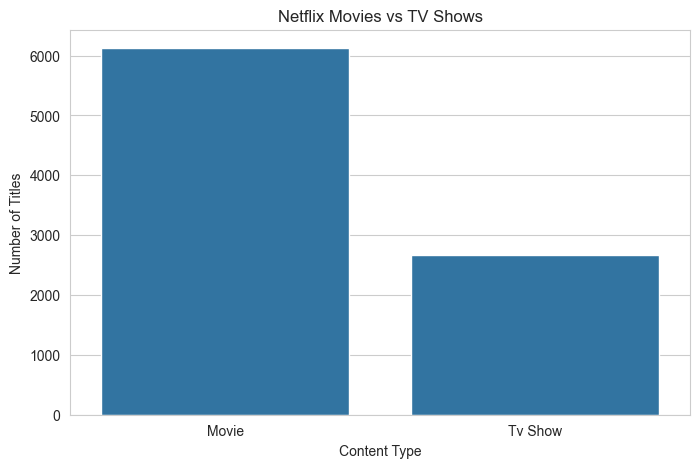

In [8]:
# visualizing the distribution of content types using a count plot

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Netflix Movies vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

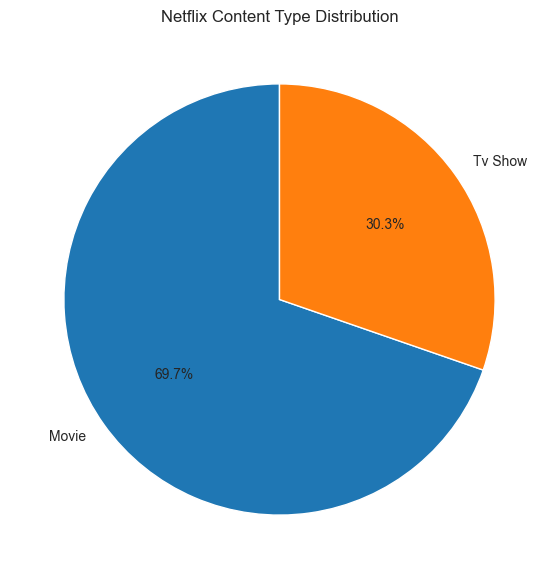

In [9]:
# visualizing the distribution of content types using a pie chart

plt.figure(figsize=(7, 7))

plt.pie(
    content_counts.values,
    labels=content_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Netflix Content Type Distribution")

plt.show()

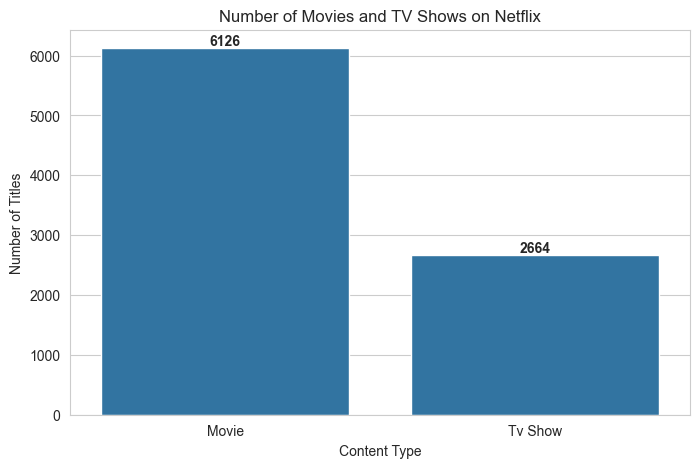

In [10]:
# visualizing the distribution of content types using a bar plot

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=content_counts.index,
    y=content_counts.values
)

plt.title("Number of Movies and TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

for i, value in enumerate(content_counts.values):
    ax.text(
        i,
        value + 50,
        str(value),
        ha="center",
        fontweight="bold"
    )

plt.show()

In [11]:
# finding the most common content type and its count

most_common_type = content_counts.idxmax()
most_common_count = content_counts.max()

print("Most Common Content Type:", most_common_type)
print("Number of Titles:", most_common_count)

Most Common Content Type: Movie
Number of Titles: 6126


In [12]:
# calculating the difference in the number of movies and TV shows

movie_count = content_counts.get("Movie", 0)
tv_show_count = content_counts.get("TV Show", 0)

difference = abs(movie_count - tv_show_count)

print("Movies:", movie_count)
print("TV Shows:", tv_show_count)
print("Difference:", difference)

Movies: 6126
TV Shows: 0
Difference: 6126


In [13]:
# providing insights based on the counts of movies and TV shows

if movie_count > tv_show_count:
    print(
        f"Insight: Movies are more common than TV Shows "
        f"by {difference} titles."
    )
elif tv_show_count > movie_count:
    print(
        f"Insight: TV Shows are more common than Movies "
        f"by {difference} titles."
    )
else:
    print("Insight: Movies and TV Shows have the same number of titles.")

Insight: Movies are more common than TV Shows by 6126 titles.
